The goal of this project is to expand on my original implementation of a small language model replicating GPT-2 with modern architecural choices: [gpt_2-update](https://github.com/lealal/gpt_2-update)

Besides the options introduced in that implementation (RMSNorm, rope, GQA, etc.), other interesting developments have taken place. To expand on the previous one, the goal here is to introduce KV_Cache to improve inference and token generation. Additionally, and the main goal, is to implement the new attention variant XSA ([Exlusive Self Attention](https://arxiv.org/pdf/2603.09078)). This new implementation, proposes that current attention places too much value in the current token. By only keeping the orthogonal information with respect to the target token, the resulting dot product results in 0, thus excluding additional information that is already captured from the current token.

In [52]:
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import time
from transformers import AutoTokenizer
import numpy as np
import math
import json
import os

Similar to my other implementation, I will use the RedPajama dataset and the gpt-2 tokenizer to keep the vocab size limited due to hardware limitations.

In [2]:
tokenizer = AutoTokenizer.from_pretrained('gpt2')

In [3]:
class LMDataset(Dataset):
    def __init__(self, tokens_path, context_length, max_tokens=None):
        self.tokens = np.memmap(tokens_path, dtype=np.uint16, mode='r')
        self.context_length = context_length
        if max_tokens is None:
            self.num_sequences = (len(self.tokens) - 1) // context_length
        else:
            # limit to max_tokens
            self.num_sequences = min((len(self.tokens) - 1) // context_length,
                                     max_tokens // context_length)

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start = idx * self.context_length

        input_tokens = self.tokens[start:start+self.context_length]
        label_tokens = self.tokens[start+1:start+self.context_length+1]

        input_tensor = torch.tensor(input_tokens, dtype=torch.long)
        target_tensor = torch.tensor(label_tokens, dtype=torch.long)

        return input_tensor, target_tensor

In [4]:
# Reusing local data generated by original notebook
train_path = 'train.bin'
val_path = 'val.bin'
test_path = 'test.bin'

CONTEXT_LENGTH = 512

train_dataset = LMDataset(train_path, CONTEXT_LENGTH)
val_dataset = LMDataset(val_path, CONTEXT_LENGTH)
test_dataset = LMDataset(test_path, CONTEXT_LENGTH)

In [5]:
# Test dataset
print(train_dataset.tokens[:10])

[15045 11942   860  4790    12 26660    12 34215   198 26953]


In [6]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [7]:
# Test dataloader
example = next(iter(train_loader))
print(example)

[tensor([[15045, 11942,   860,  ...,    11,   347,  5488],
        [   11,  1395,    13,  ...,   326,   262,  1074],
        [  290, 27686,   389,  ...,   319,  3592,    13],
        ...,
        [  898,  7883,   290,  ...,   468,  2722,  3068],
        [  422,  1811, 12527,  ...,  8429,  4129,    13],
        [  198,   464,   734,  ..., 17514,  8171,    11]]), tensor([[11942,   860,  4790,  ...,   347,  5488,    11],
        [ 1395,    13,   406,  ...,   262,  1074,   290],
        [27686,   389,   564,  ...,  3592,    13,  2773],
        ...,
        [ 7883,   290,   703,  ...,  2722,  3068,   422],
        [ 1811, 12527,   329,  ...,  4129,    13,   198],
        [  464,   734, 48924,  ...,  8171,    11,   340]])]


## Prepare the model

This implementation will follow the same architecture as my previous notebook which incorporated GQA, RMSNorm, rope, and qk_norm. In addition to it, we will add kv_cache support and the new XSA proposal

In [8]:
class RMSNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(emb_dim)).float()

    def forward(self, x):
        variance = x.pow(2).mean(dim=-1, keepdim=True)
        x_norm = x * torch.rsqrt(variance + self.eps)
        x_norm = (self.scale * x_norm).to(dtype=x.dtype)
        return x_norm

In [9]:
class MLP(nn.Module):
    def __init__(self, emb_dim, hidden_dim, dtype):
        super().__init__()
        self.fc1 = nn.Linear(emb_dim, hidden_dim, dtype=dtype)
        self.fc2 = nn.Linear(emb_dim, hidden_dim, dtype=dtype)
        self.fc3 = nn.Linear(hidden_dim, emb_dim, dtype=dtype)

    def forward(self, x):
        fc1_x = self.fc1(x)
        fc2_x = self.fc2(x)
        x = torch.nn.functional.silu(fc1_x) * fc2_x
        return self.fc3(x)

In [10]:
def compute_rope(head_dim, theta_base=10_000, context_length=CONTEXT_LENGTH):
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2).float()) / head_dim) # (head_dim / 2)

    # add batch dimension
    inv_freq = inv_freq.unsqueeze(0) # (1, head_dim / 2)

    positions = torch.arange(context_length) # (context_length)

    # add dimension for mutiplication
    positions = positions.unsqueeze(1) # (context_length, 1)
    angles = positions * inv_freq # (context_length, head_dim / 2)
    angles = torch.cat([angles, angles], dim=-1) # (context_length, head_dim)

    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin

In [11]:
def apply_rope(x, cos, sin, start_pos):
    b, n_heads, seq_length, head_dim = x.shape
    assert head_dim % 2 == 0, 'head_dim must be even'
    
    x1 = x[..., :head_dim//2]
    x2 = x[..., head_dim//2:]

    cos = cos[start_pos:start_pos+seq_length, :].unsqueeze(0).unsqueeze(0)
    sin = sin[start_pos:start_pos+seq_length, :].unsqueeze(0).unsqueeze(0)

    rotated = torch.cat((-x2, x1), dim=-1)
    x_rotated = (x*cos) + (rotated*sin)
    return x_rotated.to(dtype=x.dtype)

In [ ]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, emb_dim, context_size, num_heads, num_kv_groups, dtype, xsa=True):
        super().__init__()
        assert emb_dim % num_heads == 0, 'emb_dim must be divisible by num_heads'
        assert num_heads % num_kv_groups == 0, 'num_heads must be divisible by num_kv_groups'
        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.num_kv_groups = num_kv_groups
        self.head_dim = emb_dim // num_heads
        self.group_size = num_heads // num_kv_groups

        self.d_out = num_heads * self.head_dim
        self.W_query = nn.Linear(emb_dim, self.d_out, bias=False, dtype=dtype)
        self.W_key = nn.Linear(emb_dim, num_kv_groups * self.head_dim, bias=False, dtype=dtype)
        self.W_value = nn.Linear(emb_dim, num_kv_groups * self.head_dim, bias=False, dtype=dtype)

        self.q_norm = RMSNorm(self.head_dim, eps=1e-5)
        self.k_norm = RMSNorm(self.head_dim, eps=1e-5)

        self.out_proj = nn.Linear(emb_dim, emb_dim, bias=False, dtype=dtype)

        self.xsa = xsa

    def forward(self, x, cos, sin, start_pos=0, cache=None):
        b, seq_len, d_in = x.shape

        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        queries = queries.view(b, seq_len, self.num_heads, self.head_dim).transpose(1,2)
        keys_new = keys.view(b, seq_len, self.num_kv_groups, self.head_dim).transpose(1,2)
        values_new = (
            values.view(b, seq_len, self.num_kv_groups, self.head_dim).transpose(1,2)
        )

        queries = self.q_norm(queries)
        keys_new = self.k_norm(keys_new)

        queries = apply_rope(queries, cos, sin, start_pos)
        keys_new = apply_rope(keys_new, cos, sin, start_pos)

        if cache is None:
            keys, values = keys_new, values_new
        else:
            k_cache, v_cache = cache
            keys = torch.cat([k_cache, keys_new], dim=2)
            values = torch.cat([v_cache, values_new], dim=2)
        next_cache = (keys, values)

        is_causal = cache is None
        context_vector = torch.nn.functional.scaled_dot_product_attention(
            queries, keys, values, is_causal=is_causal, enable_gqa=True
        )

        # Apply exclusive self attention (xsa)
        if self.xsa:
            v_self = values_new.repeat_interleave(self.group_size, dim=1)
            Vn = torch.nn.functional.normalize(v_self, dim=-1)
            context_vector = context_vector - (context_vector * Vn).sum(dim=-1, keepdim=True) * Vn

        context_vector = context_vector.transpose(1,2).reshape(b, seq_len, self.d_out)
        return self.out_proj(context_vector), next_cache

In [13]:
class Transformer(nn.Module):
    def __init__(self, cfg, xsa=True):
        super().__init__()
        self.norm1 = RMSNorm(cfg['emb_dim'])
        self.norm2 = RMSNorm(cfg['emb_dim'])

        self.att = GroupedQueryAttention(
            emb_dim=cfg['emb_dim'],
            context_size=cfg['context_length'],
            num_heads=cfg['n_heads'],
            num_kv_groups=cfg['n_kv_groups'],
            dtype=cfg['dtype'],
            xsa=xsa
        )

        self.mlp = MLP(cfg['emb_dim'], cfg['hidden_dim'], dtype=cfg['dtype'])

    def forward(self, x, cos, sin, pos_start=0, cache=None):
        shortcut = x
        x = self.norm1(x)
        x, next_cache = self.att(x, cos, sin, pos_start, cache)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = x + shortcut
        return x, next_cache

In [14]:
class Model(nn.Module):
    def __init__(self, cfg, xsa=True):
        super().__init__()
        assert cfg['emb_dim'] % cfg['n_heads'] == 0, 'emb_dim must be divisible by n_heads'
        
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'], dtype=cfg['dtype'])
        self.trf_blocks = nn.ModuleList(
            [Transformer(cfg, xsa) for _ in range(cfg['n_layers'])]
        )
        self.norm = RMSNorm(cfg['emb_dim'])
        self.out_head = nn.Linear(
            cfg['emb_dim'], cfg['vocab_size'], bias=False, dtype=cfg['dtype']
        )

        self.out_head.weight = self.tok_emb.weight

        head_dim = cfg['emb_dim'] // cfg['n_heads']

        cos, sin = compute_rope(
            head_dim, theta_base=10_000, context_length=cfg['context_length']
        )

        self.register_buffer('cos', cos)
        self.register_buffer('sin', sin)

        self.current_pos = 0
        self.cfg = cfg

    def forward(self, x, cache=None):
        x = self.tok_emb(x)
        num_tokens = x.shape[1]

        start = 0
        if cache:
            start = self.current_pos
            end = self.current_pos + num_tokens
            self.current_pos = end

        for i, block in enumerate(self.trf_blocks):
            block_cache = cache.get(i) if cache else None
            x, next_cache = block(x, self.cos, self.sin, start, block_cache)
            if cache is not None:
                cache.update(i, next_cache)

        x = self.norm(x)
        logits = self.out_head(x)
        return logits

    def reset_cache(self):
        self.current_pos = 0

In [15]:
class KVCache:
    def __init__(self, n_layers):
        self.cache = [None] * n_layers

    def get(self, layer_idx):
        return self.cache[layer_idx]

    def update(self, layer_idx, value):
        self.cache[layer_idx] = value

    def get_all(self):
        return self.cache

    def reset(self):
        for i in range(len(self.cache)):
            self.cache[i] = None

#### Initialize the model

In [16]:
MODEL_CONFIG = {
    'vocab_size': 50257,
    'context_length': CONTEXT_LENGTH,
    'n_layers': 13,
    'n_heads': 8,
    'n_kv_groups': 4,
    'emb_dim': 768,
    'hidden_dim': 2048,
    'dtype': torch.bfloat16
}

model = Model(MODEL_CONFIG)

In [17]:
# Using mps, modify for cuda
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

print('Device:', device)
model.to(device)

Device: mps


Model(
  (tok_emb): Embedding(50257, 768)
  (trf_blocks): ModuleList(
    (0-12): 13 x Transformer(
      (norm1): RMSNorm()
      (norm2): RMSNorm()
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=384, bias=False)
        (W_value): Linear(in_features=768, out_features=384, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
        (out_proj): Linear(in_features=768, out_features=768, bias=False)
      )
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=2048, bias=True)
        (fc2): Linear(in_features=768, out_features=2048, bias=True)
        (fc3): Linear(in_features=2048, out_features=768, bias=True)
      )
    )
  )
  (norm): RMSNorm()
  (out_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [18]:
parameters = sum(p.numel() for p in model.parameters())
print(f'Parameters: {parameters:,}')

Parameters: 123,028,672


In [19]:
model = torch.compile(model)

### Prepare training methods

In [20]:
def train(model, train_loader, val_loader, num_epochs, optimizer, eval_freq, eval_batches,
          message_freq, tokenizer, device, warmup_steps, initial_lr, min_lr):
    train_losses, val_losses = [], []
    train_perplexities, val_perplexities = [], []
    global_step = 0
    tokens_seen = 0

    peak_lr = optimizer.param_groups[0]['lr']
    total_training_steps = len(train_loader) * num_epochs
    lr_increment = (peak_lr - initial_lr) / warmup_steps

    model.train()
    start_time = time.time()

    optimizer.zero_grad()
    for epoch in range(num_epochs):
        for i, (input_batch, target_batch) in enumerate(train_loader):
            if global_step < warmup_steps:
                lr = initial_lr + global_step * lr_increment
            else:
                progress = ((global_step - warmup_steps) /
                            (total_training_steps - warmup_steps))
                lr = (
                    min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))
                )

            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

            loss = calculate_batch_loss(model, input_batch, target_batch, device)
            loss = loss / GRAD_ACCUM_STEPS
            loss.backward()

            if (i + 1) % GRAD_ACCUM_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

            global_step += 1
            tokens_seen += input_batch.numel()

            if global_step % eval_freq == 0:
                model.eval()
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, eval_batches, device
                )
                train_ppl = calculate_perplexity(train_loss)
                val_ppl = calculate_perplexity(val_loss)

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                train_perplexities.append(train_ppl)
                val_perplexities.append(val_ppl)

                end_time = time.time()
                freq_time_min = (end_time - start_time) / 60

                print(f'Step: {global_step:06d}/{total_training_steps}. '
                      f'Train loss: {train_loss:.3f} (ppl: {train_ppl:.1f}), '
                      f'Val loss: {val_loss:.3f} (ppl: {val_ppl:.1f}). '
                      f'Elapsed: {freq_time_min:.2f}min')

                start_time = time.time()
                model.train()

            if global_step % message_freq == 0:
                generate_sample(
                    model=model,
                    tokenizer=tokenizer,
                    device=device,
                    context='Dedication will always pay',
                    context_size=MODEL_CONFIG['context_length']
                )
                torch.save({
                    'step': global_step,
                    'model': model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                }, 'gqa-xsa.pth')

    return train_losses, val_losses, train_perplexities, val_perplexities, tokens_seen

In [21]:
def calculate_batch_loss(model, input_batch, target_batch, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch) # (batch, seq_len, vocab_size)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())
    return loss

In [22]:
def evaluate_model(model, train_loader, val_loader, eval_batches, device):
    model.eval()
    with torch.no_grad():
        train_loss = calculate_loader_loss(model, train_loader, eval_batches, device)
        val_loss = calculate_loader_loss(model, val_loader, eval_batches, device)

    model.train()
    return train_loss, val_loss

In [23]:
def calculate_loader_loss(model, loader, eval_batches, device):
    total_loss = 0
    for i, (input_batch, target_batch) in enumerate(loader):
        if i < eval_batches:
            loss = calculate_batch_loss(model, input_batch, target_batch, device)
            total_loss += loss.item()
        else:
            break

    total_loss /= eval_batches
    return total_loss

In [24]:
def calculate_perplexity(loss):
    return math.exp(loss)

In [25]:
def generate_sample(model, tokenizer, device, context, context_size):
    model.eval()
    token_ids = tokenizer.encode(context, return_tensors='pt').to(device)
    with torch.no_grad():
        generated_ids = generate_text(
            model, token_ids, context_size, max_new_tokens=50
        )
    generated_text = tokenizer.decode(generated_ids[0])
    print(generated_text)
    model.train()

In [26]:
def generate_text(model, token_ids, context_size, max_new_tokens):
    for _ in range(max_new_tokens):
        # slice tokens if they exceed context_size
        token_ids_context = token_ids[:, -context_size:]

        with torch.no_grad():
            logits = model(token_ids_context)

        logits = logits[:, -1, :] # last token - ie: generated

        token_id = torch.argmax(logits, dim=-1, keepdim=True)

        token_ids = torch.cat((token_ids, token_id), dim=1) # (batch, token_ids+1)

    return token_ids

In [27]:
# Test model forward passes and generate function
generate_sample(
    model=model,
    tokenizer=tokenizer,
    device=device,
    context='Dedication will always pay',
    context_size=MODEL_CONFIG['context_length']
)

W0415 19:51:16.249000 19187 torch/_dynamo/convert_frame.py:1743] [0/8] torch._dynamo hit config.recompile_limit (8)
W0415 19:51:16.249000 19187 torch/_dynamo/convert_frame.py:1743] [0/8]    function: 'forward' (/var/folders/hj/ymtsxg694_ngqmbjhf0qmctc0000gn/T/ipykernel_19187/203403290.py:29)
W0415 19:51:16.249000 19187 torch/_dynamo/convert_frame.py:1743] [0/8]    last reason: 0/7: tensor 'x' size mismatch at index 1. expected 13, actual 14
W0415 19:51:16.249000 19187 torch/_dynamo/convert_frame.py:1743] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0415 19:51:16.249000 19187 torch/_dynamo/convert_frame.py:1743] [0/8] To diagnose recompilation issues, see https://docs.pytorch.org/docs/main/user_guide/torch_compiler/compile/programming_model.recompilation.html


Dedication will always pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay pay


In [28]:
torch.manual_seed(123)

num_epochs = 1
initial_lr = 1e-5
min_lr = 4e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4, fused=True)

# 5% warmup - paper does 2k
warmup_steps = int((len(train_loader) * num_epochs) * 0.05)

# Improve training time
GRAD_ACCUM_STEPS = 2

start_training_time = time.time()
train_losses, val_losses, train_perplexities, val_perplexities, tokens_seen = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=num_epochs,
    optimizer=optimizer,
    eval_freq=10000,
    eval_batches=10,
    message_freq=20000,
    tokenizer=tokenizer,
    device=device,
    warmup_steps=warmup_steps,
    initial_lr=initial_lr,
    min_lr=min_lr
)
end_training_time = time.time()

Step: 010000/170090. Train loss: 7.647 (ppl: 2094.1), Val loss: 7.713 (ppl: 2236.1). Elapsed: 212.73min
Step: 020000/170090. Train loss: 7.231 (ppl: 1381.9), Val loss: 7.237 (ppl: 1390.6). Elapsed: 209.98min
Dedication will always pay for the first time.
The first time, the first time, the first time, the first time, the first time, the first time, the first time, the first time, the first time, the first time, the first time,
Step: 030000/170090. Train loss: 6.766 (ppl: 867.5), Val loss: 6.709 (ppl: 820.1). Elapsed: 209.03min
Step: 040000/170090. Train loss: 6.172 (ppl: 479.1), Val loss: 6.094 (ppl: 443.1). Elapsed: 211.53min
Dedication will always pay for the first time.
The first time the first time the first time the first time the first time the first time the first time the first time the first time the first time the first time the first time the first time the first time the first
Step: 050000/170090. Train loss: 5.919 (ppl: 371.9), Val loss: 5.778 (ppl: 323.2). Elapsed: 212.93

In [29]:
torch.save({
    'step': 170090,
    'model': model.state_dict(),
    'optimizer': optimizer.state_dict(),
}, 'gqa-xsa.pth')

In [31]:
print(f'Elapsed time: {(end_training_time-start_training_time)/60:.2f} minutes')

Elapsed time: 3592.32 minutes


### Evaluation

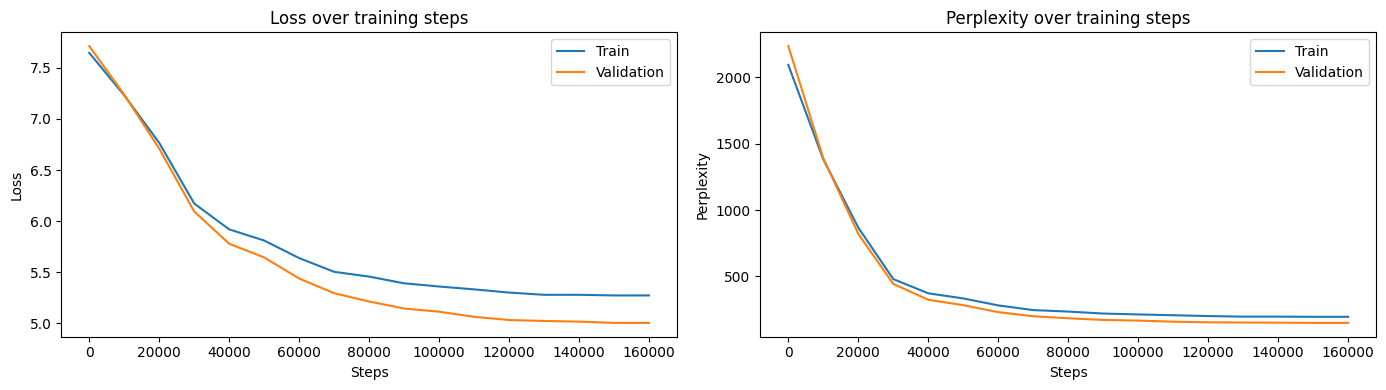

In [32]:
steps = np.arange(0, len(train_losses) * 10000, 10000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(steps, train_losses, label='Train')
ax1.plot(steps, val_losses, label='Validation')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over training steps')
ax1.legend()

ax2.plot(steps, train_perplexities, label='Train')
ax2.plot(steps, val_perplexities, label='Validation')
ax2.set_xlabel('Steps')
ax2.set_ylabel('Perplexity')
ax2.set_title('Perplexity over training steps')
ax2.legend()

plt.tight_layout()
plt.show()

In [33]:
model.eval()

with torch.no_grad():
    test_loss = calculate_loader_loss(
        model=model,
        loader=test_loader,
        eval_batches=10, 
        device=device
    )

print(f'Test loss: {test_loss:.3f}')

test_perplexity = calculate_perplexity(test_loss)
print(f'Test perplexity: {test_perplexity:.2f}')

Test loss: 5.556
Test perplexity: 258.85


In [48]:
def generate(
    model, tokenizer, prompt, device, max_new_tokens, verbose=True, top_k=None, temperature=None
):
    input_ids = torch.tensor(tokenizer.encode(prompt), device=device).unsqueeze(0)

    generated_ids = []

    print(prompt, end='', flush=True)

    for token in generate_text_stream_cache(
        model=model,
        token_ids=input_ids,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
        top_k=top_k,
        temperature=temperature
    ):
        next_token_id = token.squeeze(0)
        generated_ids.append(next_token_id.item())

        if verbose:
            print(tokenizer.decode(next_token_id.tolist()), end='', flush=True)

    return tokenizer.decode(generated_ids)

In [49]:
@torch.inference_mode()
def generate_text_stream_cache(
    model, token_ids, max_new_tokens, eos_token_id=None, top_k=None, temperature=None
):
    model.eval()
    cache = KVCache(n_layers=model.cfg['n_layers'])
    model.reset_cache()

    logits = model(token_ids, cache=cache)
    out = logits[:, -1]

    for i in range(max_new_tokens):
        if top_k is not None:
            top_logits, _ = torch.topk(out, top_k)
            min_val = top_logits[:, -1]
            out = torch.where(out < min_val, torch.tensor(float("-inf")).to(out.device), out)

        if temperature is not None and temperature > 0.0:
            out = out / temperature

            out = out - out.max(dim=-1, keepdim=True).values
            probs = torch.softmax(out, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1) 
        else:
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        if (eos_token_id is not None and next_token == eos_token_id):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [51]:
text1 = 'Dedication will always pay'
text2 = 'Large language models learn by'

text1_tokens = tokenizer.encode(text1, return_tensors='pt').to(device)
text2_tokens = tokenizer.encode(text2, return_tensors='pt').to(device)

print('Generated from example 1:\n')
generated_tokens_1 = generate(
    model=model,
    tokenizer=tokenizer,
    prompt=text1,
    device=device,
    verbose=True,
    max_new_tokens=50,
    temperature=1.2, 
    top_k=20
)
print('\n\n\nGenerated from example 2:\n')
generated_tokens_2 = generate(
    model=model,
    tokenizer=tokenizer,
    prompt=text2,
    device=device,
    verbose=True,
    max_new_tokens=50,
    temperature=1.2, 
    top_k=20
)

Generated from example 1:

Dedication will always pay attention to your own personal preferences. If you have any questions or concerns regarding your privacy or your personal preferences, your personal preferences will be considered to be a pushes against you.
You should not forget to make all the necessary steps in your personal preferences


Generated from example 2:

Large language models learn by working with an experienced computational group.
Thezero-carbon model is also an integral part of apractic system. These models make significant Wickospels and the violent and×-dLimited-to- billed Brad Pitts, a tool to the

In [53]:
metrics = {
    "model": "gqa-xsa",
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_perplexities": [p.item() if hasattr(p, "item") else p for p in train_perplexities],
    "val_perplexities": [p.item() if hasattr(p, "item") else p for p in val_perplexities],
}

metrics_path = "gqa-xsa-metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Saved metrics to {os.path.abspath(metrics_path)}")

Saved metrics to /Users/lealal/Software/MachineLearning/llm/gqa-xsa-metrics.json
